<a href="https://colab.research.google.com/github/AhmadKhdair/BinX-AI-ML-Internship/blob/main/week-7/d2/02_CNN_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Day 2: CNN Training, Data Augmentation and Transfer Learning

This notebook continues directly from the Day 1 convolution demo. The dataset is still the same binary image-classification problem with `Benign` and `Malignant` images.

For Day 2, I move from a single convolution filter to complete trainable CNNs. I first train a small CNN from scratch, then keep the same architecture and add data augmentation so I can see the effect more fairly. After that, I replace the hand-built feature extractor with a pretrained `MobileNetV2` backbone and train a new classifier for this dataset.

The comparison is based on validation results and training time. The test split stays untouched until the model choice is finished.

## 1. Day 2 Plan

| Step | What I want to check |
|---|---|
| Train a CNN from scratch | Establish a CNN result using only this dataset |
| Add data augmentation | Check whether more image variation improves validation behavior |
| Use transfer learning | Reuse pretrained visual features and train a new binary classifier |
| Compare the runs | Compare validation accuracy, AUC, loss, epochs, and training time |
| Fine-tune the pretrained model | Check whether adapting a small part of the backbone gives another improvement |
| Final test evaluation | Evaluate only after the validation-based model choice is complete |

I am reusing `EarlyStopping` and `ReduceLROnPlateau` from the previous week. They are not the main topic today, but they make the comparison cleaner because a model is not forced to keep training after validation has stopped improving.

## 2. Imports and Reproducibility

I keep one random seed for the dataset split and model initialization. This does not make GPU training perfectly identical on every machine, but it removes avoidable randomness and makes the experiments easier to compare.

In [1]:
from pathlib import Path
import os
import shutil
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU available: True


A GPU is not required for correctness, but it is strongly recommended for the three training runs and the fine-tuning step. In Colab I use a GPU runtime when it is available.

## 3. Locate and Extract the Dataset

I keep the same archive workflow as Day 1. Locally, the notebook searches for the zip beside the notebook. In Colab, if the file is not already present, it asks for the archive upload.

The expected structure is:

```text
train/
  Benign/
  Malignant/
test/
  Benign/
  Malignant/
```

In [2]:
def running_in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def find_dataset_archive():
    cwd = Path.cwd().resolve()
    env_path = os.environ.get("WEEK7_IMAGE_ARCHIVE")

    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser())

    candidates.extend([
        cwd / "archive.zip",
        cwd / "archive (3).zip",
        cwd / "dataset.zip",
        cwd / "data" / "archive.zip",
        cwd / "data" / "archive (3).zip",
        cwd / "data" / "dataset.zip",
    ])

    for path in candidates:
        if path.exists() and path.suffix.lower() == ".zip":
            return path.resolve()

    local_zips = sorted(cwd.glob("*.zip"))
    if (cwd / "data").exists():
        local_zips += sorted((cwd / "data").glob("*.zip"))

    if local_zips:
        return local_zips[0].resolve()

    if running_in_colab():
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No dataset archive was uploaded.")
        first_name = next(iter(uploaded))
        return (cwd / first_name).resolve()

    raise FileNotFoundError(
        "Dataset archive was not found. Put the zip beside the notebook "
        "or set WEEK7_IMAGE_ARCHIVE to its full path."
    )


def find_split_directory(root: Path, split_name: str):
    candidates = [
        path for path in root.rglob("*")
        if path.is_dir() and path.name.lower() == split_name.lower()
    ]

    for path in candidates:
        child_names = {p.name.lower() for p in path.iterdir() if p.is_dir()}
        if {"benign", "malignant"}.issubset(child_names):
            return path

    raise FileNotFoundError(
        f"Could not find a '{split_name}' directory containing "
        "Benign and Malignant class folders."
    )


DATASET_ZIP = find_dataset_archive()

if running_in_colab():
    EXTRACT_ROOT = Path("/content/week7_day2_data")
else:
    EXTRACT_ROOT = Path.home() / ".cache" / "binx_week7_day2_data"

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

try:
    TRAIN_DIR = find_split_directory(EXTRACT_ROOT, "train")
    TEST_DIR = find_split_directory(EXTRACT_ROOT, "test")
except FileNotFoundError:
    with zipfile.ZipFile(DATASET_ZIP) as zf:
        zf.extractall(EXTRACT_ROOT)

    TRAIN_DIR = find_split_directory(EXTRACT_ROOT, "train")
    TEST_DIR = find_split_directory(EXTRACT_ROOT, "test")

print("Archive:", DATASET_ZIP)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Saving archive (3).zip to archive (3).zip
Archive: /content/archive (3).zip
Train directory: /content/week7_day2_data/train
Test directory: /content/week7_day2_data/test


## 4. Quick Dataset Audit

Before training, I verify the class counts again instead of assuming that the archive is unchanged. The Day 1 audit showed a slightly larger `Benign` training class, but the difference was small enough that I did not need class weighting.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def count_images(class_dir: Path):
    return sum(
        1
        for path in class_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

rows = []
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        rows.append({
            "split": split_name,
            "label": class_dir.name,
            "images": count_images(class_dir),
        })

dataset_counts = pd.DataFrame(rows)
display(dataset_counts)

train_counts = dataset_counts[dataset_counts["split"] == "train"]["images"]
train_imbalance_ratio = train_counts.max() / train_counts.min()

print(f"Training max/min class ratio: {train_imbalance_ratio:.3f}")
if train_imbalance_ratio < 1.25:
    print("The training split is close enough to balanced for this experiment; class weights are not necessary.")
else:
    print("The class imbalance is large enough that class weighting should be considered before training.")

,split,label,images
0,train,Benign,6289
1,train,Malignant,5590
2,test,Benign,1000
3,test,Malignant,1000


Training max/min class ratio: 1.125
The training split is close enough to balanced for this experiment; class weights are not necessary.


The count check is important because accuracy can look strong even when one class dominates. If the class ratio is close to 1, accuracy is still useful here, while recall and AUC give extra information about the binary classifier.

## 5. Build Train, Validation and Test Datasets

The original `test/` directory stays untouched. I split only the original training directory into training and validation subsets.

I resize images to `160 x 160` for training. This is smaller than the original `224 x 224` images, which reduces training cost, and `MobileNetV2` supports this input size.

In [4]:
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

class_names = train_ds.class_names
assert class_names == val_ds.class_names == test_ds.class_names
assert "Malignant" in class_names

print("Classes:", class_names)
print("Positive class for precision/recall:", "Malignant")

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.
Classes: ['Benign', 'Malignant']
Positive class for precision/recall: Malignant


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape: (32, 160, 160, 3)
Label batch shape: (32, 1)
Pixel range: 0.0 to 255.0


The loader returns batches shaped approximately as `(batch, height, width, channels)`. The images are still in their normal pixel range at this point. Each model handles its own preprocessing so the scratch CNN and pretrained network do not accidentally use the wrong input scaling.

## 6. Data Augmentation

The augmentation layers create a new variation during training instead of permanently changing the stored image. I use transformations that should not change whether a lesion is benign or malignant: horizontal flipping, small rotations, small zoom changes, and mild contrast changes.

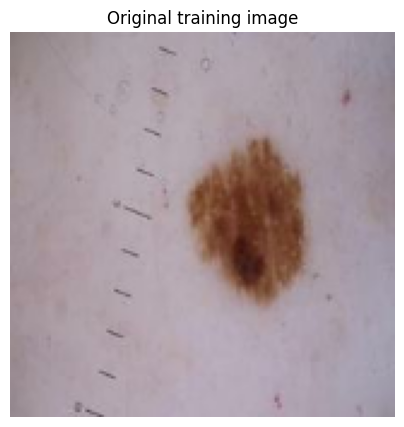

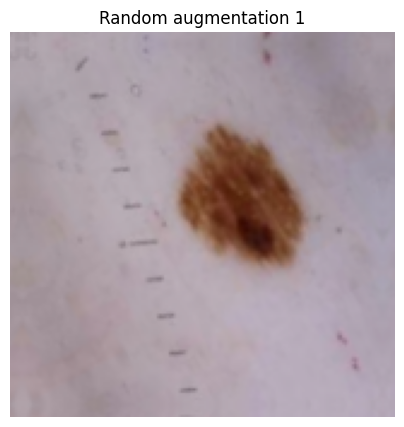

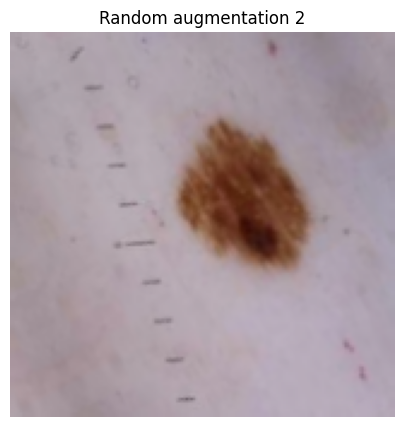

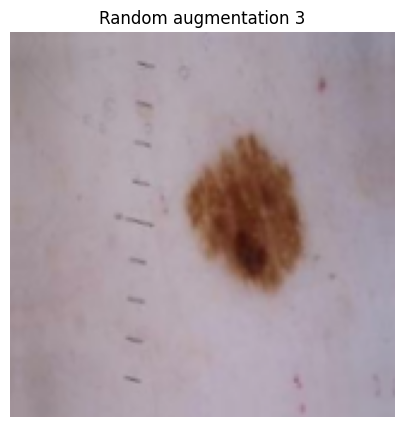

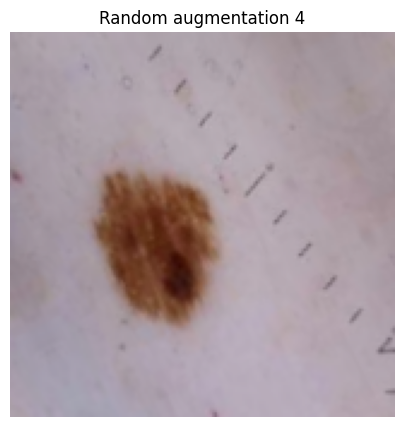

In [6]:
def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ], name="data_augmentation")


preview_augmentation = make_augmentation()
sample_image = images[0:1]

plt.figure(figsize=(5, 5))
plt.imshow(tf.cast(sample_image[0], tf.uint8))
plt.title("Original training image")
plt.axis("off")
plt.show()

for i in range(4):
    augmented = preview_augmentation(sample_image, training=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(tf.cast(tf.clip_by_value(augmented[0], 0, 255), tf.uint8))
    plt.title(f"Random augmentation {i + 1}")
    plt.axis("off")
    plt.show()

The four versions come from the same stored image, but the random transformations are sampled again each time. This is the behavior I want during training: more variation without duplicating thousands of image files on disk.

## 7. Shared Training Utilities

To keep the experiments comparable, I use the same metric set and the same early-stopping rule. Each result is summarized at the epoch with the lowest validation loss.

For this medical-image classification exercise I keep accuracy because it is part of the Day 2 comparison, and I also track recall and ROC-AUC so the result is not reduced to one percentage.

In [7]:
MODEL_DIR = Path("/content/day2_models") if running_in_colab() else Path.home() / ".cache" / "binx_week7_day2_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

experiment_rows = []


def binary_metrics():
    return [
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]


def compile_binary_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=binary_metrics(),
    )


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
    ]


def plot_history(history, title):
    epochs = np.arange(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history["loss"], label="train")
    plt.plot(epochs, history.history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history["accuracy"], label="train")
    plt.plot(epochs, history.history["val_accuracy"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()


def record_experiment(name, model, history, elapsed_seconds, model_path):
    best_index = int(np.argmin(history.history["val_loss"]))

    row = {
        "experiment": name,
        "epochs_run": len(history.history["loss"]),
        "best_epoch": best_index + 1,
        "best_val_loss": history.history["val_loss"][best_index],
        "train_accuracy": history.history["accuracy"][best_index],
        "val_accuracy": history.history["val_accuracy"][best_index],
        "val_recall": history.history["val_recall"][best_index],
        "val_auc": history.history["val_auc"][best_index],
        "generalization_gap": (
            history.history["accuracy"][best_index]
            - history.history["val_accuracy"][best_index]
        ),
        "trainable_params": int(
            np.sum([np.prod(v.shape) for v in model.trainable_weights])
        ),
        "train_time_sec": elapsed_seconds,
        "model_path": str(model_path),
    }

    experiment_rows.append(row)
    return row

## 8. Experiment 1 - CNN From Scratch

This is the reference CNN for Day 2. All convolution and dense weights start randomly and must be learned from this dataset.

I use three convolution blocks. `padding="same"` keeps the spatial size stable inside each convolution, while max pooling reduces the height and width after every block. The final feature maps are flattened before the dense classifier, matching the CNN structure covered today.

In [8]:
def build_scratch_cnn(use_augmentation=False):
    keras.utils.set_random_seed(RANDOM_STATE)

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
    x = inputs

    if use_augmentation:
        x = make_augmentation()(x)

    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    name = "scratch_cnn_augmented" if use_augmentation else "scratch_cnn"
    return keras.Model(inputs, outputs, name=name)


scratch_model = build_scratch_cnn(use_augmentation=False)
compile_binary_model(scratch_model, learning_rate=1e-3)
scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

The last layer has one sigmoid output because this is binary classification. The loss is binary cross-entropy for the same reason.

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.7808 - auc: 0.8597 - loss: 0.4614 - precision: 0.8049 - recall: 0.7015 - val_accuracy: 0.8227 - val_auc: 0.9195 - val_loss: 0.3745 - val_precision: 0.8187 - val_recall: 0.8122 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8341 - auc: 0.9153 - loss: 0.3680 - precision: 0.8361 - recall: 0.8025 - val_accuracy: 0.8366 - val_auc: 0.9167 - val_loss: 0.3695 - val_precision: 0.8311 - val_recall: 0.8297 - learning_rate: 0.0010
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8497 - auc: 0.9291 - loss: 0.3382 - precision: 0.8435 - recall: 0.8333 - val_accuracy: 0.8463 - val_auc: 0.9354 - val_loss: 0.3374 - val_precision: 0.8839 - val_recall: 0.7843 - learning_rate: 0.0010
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8611 - auc: 0.9360 - loss: 0.3214 - precision: 0.8512 - recall: 0.8520 - val_accuracy: 0.8316 - val_auc: 0.9274 - val_loss: 0.34

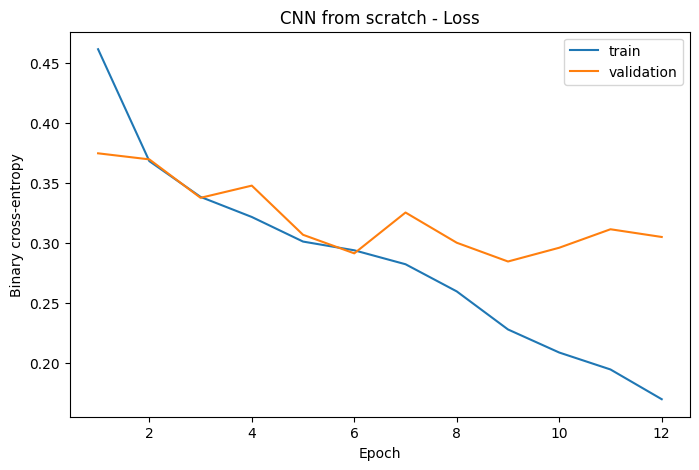

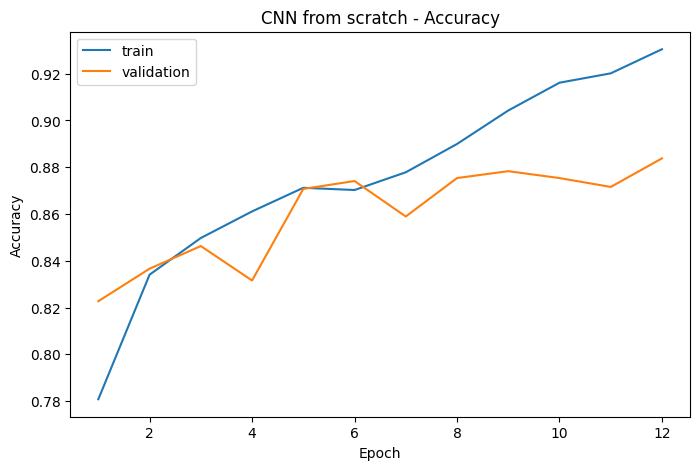

In [9]:
start = time.perf_counter()

scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=make_callbacks(),
    verbose=1,
)

scratch_time = time.perf_counter() - start
scratch_path = MODEL_DIR / "scratch_cnn.keras"
scratch_model.save(scratch_path)

scratch_result = record_experiment(
    "CNN from scratch",
    scratch_model,
    scratch_history,
    scratch_time,
    scratch_path,
)

print(f"Training time: {scratch_time / 60:.2f} minutes")
print(f"Best validation accuracy: {scratch_result['val_accuracy']:.2%}")
print(f"Best validation AUC: {scratch_result['val_auc']:.4f}")
print(f"Accuracy gap at best epoch: {scratch_result['generalization_gap']:.2%}")

plot_history(scratch_history, "CNN from scratch")

The important part of this output is not training accuracy by itself. I look at the validation curve and the train-validation gap. If training accuracy keeps improving while validation stalls or gets worse, the model is starting to overfit.

## 9. Experiment 2 - Same CNN With Data Augmentation

For a fair comparison, I keep the CNN architecture, optimizer, batch size, and stopping rule the same. The only intended change is the augmentation block before the CNN.

This lets me connect the idea directly to the result instead of changing several hyperparameters at once.

In [10]:
del scratch_model
keras.backend.clear_session()

aug_model = build_scratch_cnn(use_augmentation=True)
compile_binary_model(aug_model, learning_rate=1e-3)
aug_model.summary()

Model: "scratch_cnn_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.7446 - auc: 0.8256 - loss: 0.5181 - precision: 0.7709 - recall: 0.6459 - val_accuracy: 0.7949 - val_auc: 0.9077 - val_loss: 0.4457 - val_precision: 0.7208 - val_recall: 0.9380 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.8194 - auc: 0.9043 - loss: 0.3915 - precision: 0.8057 - recall: 0.8090 - val_accuracy: 0.8387 - val_auc: 0.9230 - val_loss: 0.3621 - val_precision: 0.8594 - val_recall: 0.7956 - learning_rate: 0.0010
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.8411 - auc: 0.9157 - loss: 0.3700 - precision: 0.8353 - recall: 0.8225 - val_accuracy: 0.8375 - val_auc: 0.9168 - val_loss: 0.3684 - val_precision: 0.8192 - val_recall: 0.8507 - learning_rate: 0.0010
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.8423 - auc: 0.9212 - loss: 0.3547 - precision: 0.8286 - recall: 0.8355 - val_accuracy: 0.8484 - val_auc: 0.9314 - val_loss: 0.35

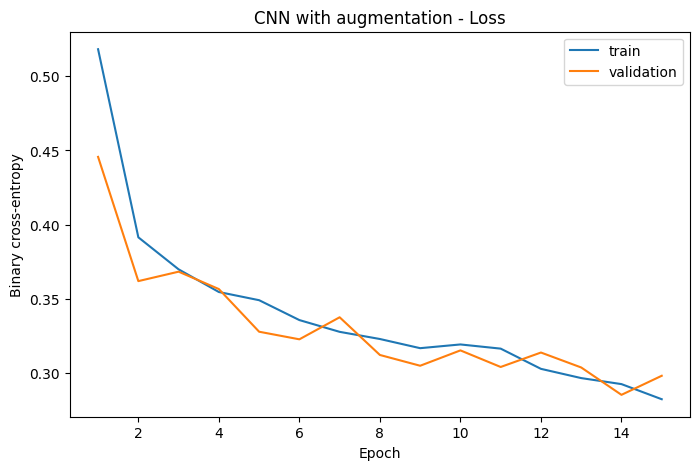

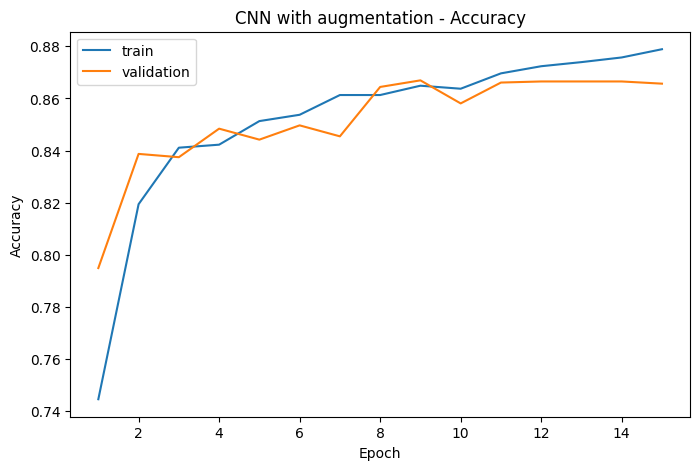

In [11]:
start = time.perf_counter()

aug_history = aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=make_callbacks(),
    verbose=1,
)

aug_time = time.perf_counter() - start
aug_path = MODEL_DIR / "scratch_cnn_augmented.keras"
aug_model.save(aug_path)

aug_result = record_experiment(
    "CNN + augmentation",
    aug_model,
    aug_history,
    aug_time,
    aug_path,
)

print(f"Training time: {aug_time / 60:.2f} minutes")
print(f"Best validation accuracy: {aug_result['val_accuracy']:.2%}")
print(f"Best validation AUC: {aug_result['val_auc']:.4f}")
print(f"Accuracy gap at best epoch: {aug_result['generalization_gap']:.2%}")

plot_history(aug_history, "CNN with augmentation")

In [12]:
delta_acc = aug_result["val_accuracy"] - scratch_result["val_accuracy"]
delta_gap = aug_result["generalization_gap"] - scratch_result["generalization_gap"]

print(f"Validation accuracy change: {delta_acc:+.2%}")
print(f"Generalization-gap change: {delta_gap:+.2%}")

if delta_acc > 0 and delta_gap < 0:
    print("Augmentation improved validation accuracy and reduced the train-validation gap.")
elif delta_acc > 0:
    print("Augmentation improved validation accuracy, although the train-validation gap did not become smaller.")
elif delta_gap < 0:
    print("Augmentation reduced the train-validation gap, but it did not improve the best validation accuracy.")
else:
    print("This augmentation setup did not improve the validation result, so I would revisit the transformations rather than assume augmentation always helps.")

Validation accuracy change: -1.18%
Generalization-gap change: -1.67%
Augmentation reduced the train-validation gap, but it did not improve the best validation accuracy.


The augmented CNN gave a cleaner generalization pattern, but it did not beat the plain scratch CNN on the validation set. The best validation accuracy changed from `87.83%` to `86.65%` (`-1.18%`), while the train-validation accuracy gap dropped from `2.59%` to `0.92%`.

So I would not describe augmentation as a direct accuracy improvement in this run. Its useful effect here was regularization: the training and validation curves stayed closer, and validation loss kept improving more smoothly until epoch 14. The trade-off is that the best validation accuracy was slightly lower and training took longer (`3.25` min vs `2.84` min).


## 10. Experiment 3 - Transfer Learning With MobileNetV2

The first two models had to learn visual features from this dataset. In this experiment I reuse a CNN that already learned visual representations from ImageNet.

`include_top=False` removes MobileNetV2's original ImageNet classifier. I freeze the pretrained backbone, add my own binary classification head, and train only the new head first.

I keep augmentation in this experiment because it was already introduced as part of the image-training pipeline. The main change relative to Experiment 2 is the feature extractor: hand-built CNN versus pretrained MobileNetV2.

In [13]:
del aug_model
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
)

base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
x = make_augmentation()(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.20)(x)
outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

transfer_model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
compile_binary_model(transfer_model, learning_rate=1e-3)

transfer_model.summary()

print("Backbone trainable:", base_model.trainable)
print("Backbone layers:", len(base_model.layers))
print("Trainable model parameters:",
      int(np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Backbone trainable: False
Backbone layers: 154
Trainable model parameters: 1281


`GlobalAveragePooling2D` is used here instead of flattening all MobileNet feature maps. It produces a much smaller classifier head, which is useful because the pretrained backbone already did the heavy feature-extraction work.

The backbone has many parameters, but while it is frozen they are not updated by the optimizer. The new classification head is the part learning how pretrained visual features map to `Benign` or `Malignant`.

Epoch 1/12
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7807 - auc: 0.8618 - loss: 0.4603 - precision: 0.7830 - recall: 0.7348 - val_accuracy: 0.8358 - val_auc: 0.9201 - val_loss: 0.3684 - val_precision: 0.8848 - val_recall: 0.7581 - learning_rate: 0.0010
Epoch 2/12
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8343 - auc: 0.9134 - loss: 0.3706 - precision: 0.8391 - recall: 0.7989 - val_accuracy: 0.8421 - val_auc: 0.9260 - val_loss: 0.3629 - val_precision: 0.8994 - val_recall: 0.7572 - learning_rate: 0.0010
Epoch 3/12
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8463 - auc: 0.9232 - loss: 0.3489 - precision: 0.8529 - recall: 0.8112 - val_accuracy: 0.8484 - val_auc: 0.9278 - val_loss: 0.3565 - val_precision: 0.9059 - val_recall: 0.7651 - learning_rate: 0.0010
Epoch 4/12
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.8454 - auc: 0.9236 - loss: 0.3477 - precision: 0.8486 - recall: 0.8148 - val_accuracy: 0.8459 - val_auc: 0.9292 - val_loss: 0.36

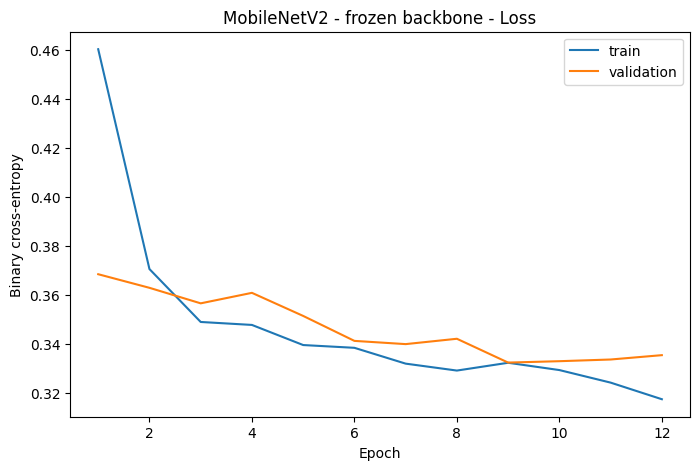

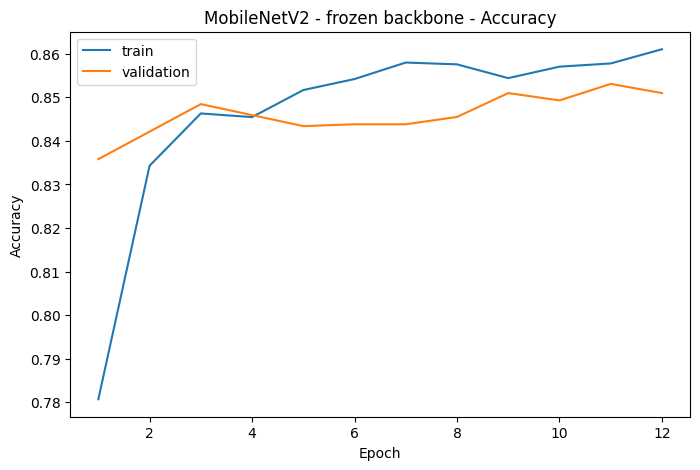

In [14]:
start = time.perf_counter()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=make_callbacks(),
    verbose=1,
)

transfer_time = time.perf_counter() - start
transfer_path = MODEL_DIR / "mobilenetv2_frozen.keras"
transfer_model.save(transfer_path)

transfer_result = record_experiment(
    "MobileNetV2 frozen",
    transfer_model,
    transfer_history,
    transfer_time,
    transfer_path,
)

print(f"Training time: {transfer_time / 60:.2f} minutes")
print(f"Best validation accuracy: {transfer_result['val_accuracy']:.2%}")
print(f"Best validation AUC: {transfer_result['val_auc']:.4f}")

plot_history(transfer_history, "MobileNetV2 - frozen backbone")

The frozen MobileNetV2 run did not win on this dataset. It reached `85.09%` validation accuracy and `0.9326` validation AUC, below both scratch CNN runs. It also had the smallest train-validation gap (`0.34%`), which means it was stable, but mostly because the frozen backbone plus small head underfit the task compared with the scratch CNN.

This is a useful result because transfer learning is not automatically better. With only `1,281` trainable parameters in the frozen run, the classifier head had limited ability to adapt ImageNet features to these lesion images.


## 11. Small Extension - Fine-Tuning the Last Part of MobileNetV2

The required transfer-learning run is already complete with the frozen backbone. I add one controlled fine-tuning step because freezing and fine-tuning are both part of today's topic.

I start from the trained transfer-learning model, unfreeze only the last part of MobileNetV2, keep batch-normalization layers frozen, and reduce the learning rate from `1e-3` to `1e-5`. The small learning rate is important because I want to adapt pretrained features, not overwrite them aggressively.

In [15]:
base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

compile_binary_model(transfer_model, learning_rate=1e-5)

trainable_backbone_layers = sum(layer.trainable for layer in base_model.layers)

print("Trainable backbone layers:", trainable_backbone_layers)
print("Total backbone layers:", len(base_model.layers))
print("Trainable model parameters:",
      int(np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])))

Trainable backbone layers: 19
Total backbone layers: 154
Trainable model parameters: 1512001


Epoch 1/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.8587 - auc: 0.9339 - loss: 0.3237 - precision: 0.8622 - recall: 0.8306 - val_accuracy: 0.8526 - val_auc: 0.9354 - val_loss: 0.3316 - val_precision: 0.8886 - val_recall: 0.7939 - learning_rate: 1.0000e-05
Epoch 2/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8704 - auc: 0.9410 - loss: 0.3066 - precision: 0.8751 - recall: 0.8432 - val_accuracy: 0.8556 - val_auc: 0.9397 - val_loss: 0.3201 - val_precision: 0.8893 - val_recall: 0.8000 - learning_rate: 1.0000e-05
Epoch 3/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8788 - auc: 0.9484 - loss: 0.2864 - precision: 0.8841 - recall: 0.8526 - val_accuracy: 0.8543 - val_auc: 0.9429 - val_loss: 0.3206 - val_precision: 0.8999 - val_recall: 0.7852 - learning_rate: 1.0000e-05
Epoch 4/8
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8811 - auc: 0.9521 - loss: 0.2759 - precision: 0.8847 - recall: 0.8576 - val_accuracy: 0.8678 - val_auc: 0.9444 - val_lo

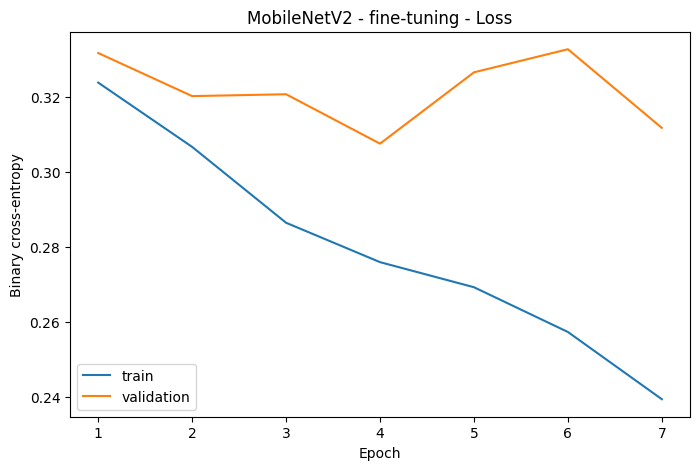

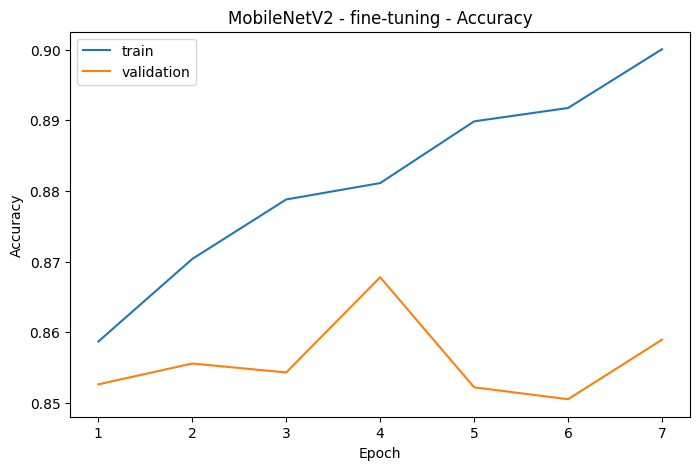

In [16]:
start = time.perf_counter()

finetune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=make_callbacks(),
    verbose=1,
)

finetune_time = time.perf_counter() - start
finetune_path = MODEL_DIR / "mobilenetv2_finetuned.keras"
transfer_model.save(finetune_path)

finetune_result = record_experiment(
    "MobileNetV2 fine-tuned",
    transfer_model,
    finetune_history,
    finetune_time,
    finetune_path,
)

print(f"Fine-tuning time: {finetune_time / 60:.2f} minutes")
print(f"Best validation accuracy: {finetune_result['val_accuracy']:.2%}")
print(f"Best validation AUC: {finetune_result['val_auc']:.4f}")

plot_history(finetune_history, "MobileNetV2 - fine-tuning")

Fine-tuning improved over the frozen MobileNetV2 head, but it still did not pass the scratch CNN. Validation accuracy improved from `85.09%` to `86.78%`, and validation AUC improved from `0.9326` to `0.9444`.

The curves show the risk clearly: training kept improving, while validation accuracy peaked around epoch 4 and then became unstable. Keeping BatchNorm layers frozen and using `1e-5` helped avoid a collapse, but the fine-tuned model was still not the best validation choice.


## 12. Compare the Experiments

The Day 2 requirement is to compare the scratch CNN, augmentation, and frozen transfer-learning model. I also keep the fine-tuned run in the table as an extension.

The table is sorted by validation accuracy. The test set is still not used here.

In [17]:
comparison = pd.DataFrame(experiment_rows).copy()

comparison["val_accuracy_pct"] = 100 * comparison["val_accuracy"]
comparison["train_accuracy_pct"] = 100 * comparison["train_accuracy"]
comparison["generalization_gap_pct"] = 100 * comparison["generalization_gap"]
comparison["train_time_min"] = comparison["train_time_sec"] / 60

comparison_view = comparison[[
    "experiment",
    "epochs_run",
    "best_epoch",
    "best_val_loss",
    "train_accuracy_pct",
    "val_accuracy_pct",
    "val_recall",
    "val_auc",
    "generalization_gap_pct",
    "trainable_params",
    "train_time_min",
]].sort_values(
    ["val_accuracy_pct", "val_auc"],
    ascending=False,
)

display(comparison_view.round({
    "best_val_loss": 4,
    "train_accuracy_pct": 2,
    "val_accuracy_pct": 2,
    "val_recall": 4,
    "val_auc": 4,
    "generalization_gap_pct": 2,
    "train_time_min": 2,
}))

,experiment,epochs_run,best_epoch,best_val_loss,train_accuracy_pct,val_accuracy_pct,val_recall,val_auc,generalization_gap_pct,trainable_params,train_time_min
0,CNN from scratch,12,9,0.2843,90.43,87.83,0.8786,0.9534,2.59,6647105,2.84
3,MobileNetV2 fine-tuned,7,4,0.3075,88.11,86.78,0.8218,0.9444,1.33,1512001,2.07
1,CNN + augmentation,15,14,0.2855,87.57,86.65,0.8873,0.9502,0.92,6647105,3.25
2,MobileNetV2 frozen,12,9,0.3324,85.44,85.09,0.8017,0.9326,0.34,1281,3.04


In [18]:
required_names = {
    "CNN from scratch",
    "CNN + augmentation",
    "MobileNetV2 frozen",
}

required_comparison = comparison[
    comparison["experiment"].isin(required_names)
].sort_values(
    ["val_accuracy", "val_auc"],
    ascending=False,
)

required_best = required_comparison.iloc[0]

print(
    f"Best required Day 2 approach: {required_best['experiment']} "
    f"with {required_best['val_accuracy']:.2%} validation accuracy "
    f"and {required_best['val_auc']:.4f} validation AUC."
)

scratch = comparison.set_index("experiment").loc["CNN from scratch"]
augmented = comparison.set_index("experiment").loc["CNN + augmentation"]
frozen = comparison.set_index("experiment").loc["MobileNetV2 frozen"]

print()
print("What changed:")
print(
    f"- Augmentation vs scratch: "
    f"{augmented['val_accuracy'] - scratch['val_accuracy']:+.2%} validation accuracy."
)
print(
    f"- Frozen MobileNetV2 vs augmented scratch CNN: "
    f"{frozen['val_accuracy'] - augmented['val_accuracy']:+.2%} validation accuracy."
)
print(
    f"- Frozen MobileNetV2 training time: {frozen['train_time_sec'] / 60:.2f} min; "
    f"augmented scratch CNN: {augmented['train_time_sec'] / 60:.2f} min."
)

Best required Day 2 approach: CNN from scratch with 87.83% validation accuracy and 0.9534 validation AUC.

What changed:
- Augmentation vs scratch: -1.18% validation accuracy.
- Frozen MobileNetV2 vs augmented scratch CNN: -1.56% validation accuracy.
- Frozen MobileNetV2 training time: 3.04 min; augmented scratch CNN: 3.25 min.


I use the validation split for model selection because the test split should stay untouched until the end. Based on validation accuracy, with validation AUC as the tie-breaker, the selected model is the CNN from scratch: `87.83%` validation accuracy, `0.9534` validation AUC, and `0.2843` best validation loss.

The model is not selected because it is the simplest or most complex option. It is selected because it produced the strongest validation result among the completed experiments.


## 13. Final Held-Out Test Evaluation

For the final model choice I consider all completed experiments, including fine-tuning, and select by validation accuracy with validation AUC as a tie-breaker.

After this point I do not make another model change based on the test result.

In [19]:
best_row = comparison.sort_values(
    ["val_accuracy", "val_auc"],
    ascending=False,
).iloc[0]

best_model_path = Path(best_row["model_path"])
best_model = keras.models.load_model(best_model_path)

print("Selected model:", best_row["experiment"])
print("Saved model:", best_model_path)

test_metrics = best_model.evaluate(test_ds, return_dict=True, verbose=1)

print()
for name, value in test_metrics.items():
    if name == "loss":
        print(f"{name}: {value:.4f}")
    else:
        print(f"{name}: {value:.4f} ({value:.2%})" if name in {"accuracy", "precision", "recall"} else f"{name}: {value:.4f}")

Selected model: CNN from scratch
Saved model: /content/day2_models/scratch_cnn.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9050 - auc: 0.9684 - loss: 0.2400 - precision: 0.9272 - recall: 0.8790

accuracy: 0.9050 (90.50%)
auc: 0.9684
loss: 0.2400
precision: 0.9272 (92.72%)
recall: 0.8790 (87.90%)


The held-out test result is the final check, not another tuning step. The selected scratch CNN reached `90.50%` test accuracy and `0.9685` ROC-AUC.

For this binary medical-image task, I care about the malignant recall specifically. The test confusion matrix shows `121` malignant images predicted as benign, so the final model is strong overall but still misses some positive cases at the default `0.5` threshold.


In [20]:
y_true = np.concatenate([
    y.numpy().reshape(-1)
    for _, y in test_ds
]).astype(int)

y_prob = best_model.predict(test_ds, verbose=1).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

malignant_index = class_names.index("Malignant")

if malignant_index != 1:
    raise ValueError(
        "This notebook expects 'Malignant' to be encoded as class 1 "
        "for sigmoid thresholding and binary metrics."
    )

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
))

print("Test ROC-AUC:", f"{roc_auc_score(y_true, y_prob):.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

      Benign     0.8850    0.9310    0.9074      1000
   Malignant     0.9272    0.8790    0.9025      1000

    accuracy                         0.9050      2000
   macro avg     0.9061    0.9050    0.9049      2000
weighted avg     0.9061    0.9050    0.9049      2000

Test ROC-AUC: 0.9685


<Figure size 600x500 with 0 Axes>

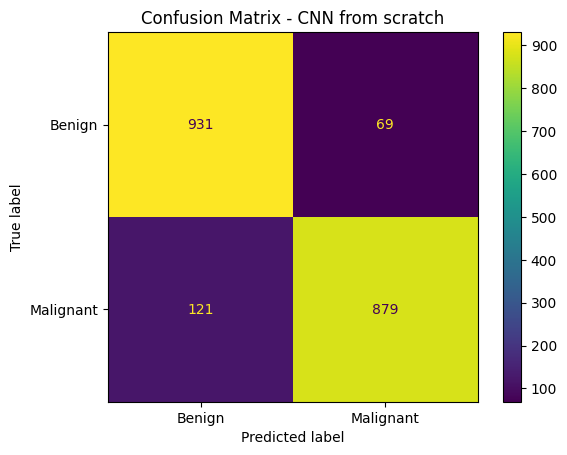

True negatives:  931
False positives: 69
False negatives: 121
True positives:  879


In [21]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

plt.figure(figsize=(6, 5))
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_row['experiment']}")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

## 14. Final Reading

This notebook is ready for the Week 7 Day 2 requirement. It includes the required scratch CNN, data augmentation comparison, frozen MobileNetV2 transfer learning run, training-time comparison, and a validation-based explanation of which approach performed best. Fine-tuning is included as an extra step, but it does not replace the required frozen-backbone experiment.

The best required Day 2 model was the CNN from scratch. It reached `87.83%` validation accuracy, `0.9534` validation AUC, and `0.2843` validation loss in `2.84` minutes. The augmented CNN reduced the generalization gap from `2.59%` to `0.92%`, but its best validation accuracy was lower at `86.65%`. Frozen MobileNetV2 was stable but weaker (`85.09%` validation accuracy), and fine-tuning improved MobileNetV2 to `86.78%` without beating the scratch CNN.

The final held-out test evaluation was done once after model selection. The selected scratch CNN reached `90.50%` accuracy, `92.72%` malignant precision, `87.90%` malignant recall, and `0.9685` ROC-AUC. The confusion matrix had `931` true benign predictions, `879` true malignant predictions, `69` false positives, and `121` false negatives.

My main conclusion is that augmentation helped regularize the scratch CNN but did not improve its best validation accuracy. Transfer learning was useful to test, but the frozen MobileNetV2 head underfit this dataset, and the small fine-tuning step improved it only partially. For this submitted run, the scratch CNN is the correct final choice based on validation performance, with the test split used only for the final report.
